# 1. Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import warnings

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# 2. Load the data set

In [4]:
# Load the dataset
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

In [7]:
print('Shape of the features:', X.shape)
print('Shape of the targets', y.shape)

Shape of the features: (150, 4)
Shape of the targets (150,)


In [8]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
target_names = iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


In [10]:
target_dict = dict(enumerate(target_names))
y_names = y.map(target_dict)
y_names.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

# 3. Plot the dataset

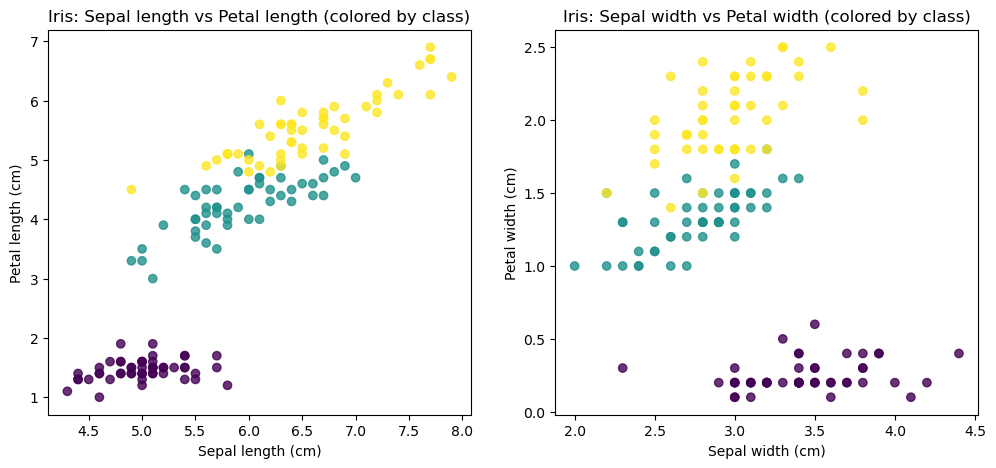

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(
    X['sepal length (cm)'],
    X['petal length (cm)'],
    c=y,
    alpha=0.8
)

ax2.scatter(
    X['sepal width (cm)'],
    X['petal width (cm)'],
    c=y,
    alpha=0.8
)

ax1.set_xlabel('Sepal length (cm)')
ax1.set_ylabel('Petal length (cm)')
ax1.set_title('Iris: Sepal length vs Petal length (colored by class)')

ax2.set_xlabel('Sepal width (cm)')
ax2.set_ylabel('Petal width (cm)')
ax2.set_title('Iris: Sepal width vs Petal width (colored by class)')

plt.show()

# 4. Split the data for training and testing

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 120
Test size: 30


# 6. Set up a baseline using a dummy classifier

In [13]:
# Initialize the dummy classifier
baseline = DummyClassifier(
    strategy='most_frequent',
    random_state=SEED
)

# Train the classifier
baseline.fit(X_train,y_train)

# Apply the trained model to the test set
y_pred_base = baseline.predict(X_test)

# Evalute the predicts using the accuracy score
accuracy_base = accuracy_score(y_test, y_pred_base)

print(f"Baseline accuracy (most frequent class): {accuracy_base:.3f}")

Baseline accuracy (most frequent class): 0.333


# 7. Using KNN classifier

In [14]:
# Create a pipeline for data preprocessing
knn_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]
)

# Train the model using the pipeline
knn_pipeline.fit(X_train, y_train)

# Evaluate the trained model on the test set
y_pred = knn_pipeline.predict(X_test)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred)

print(f"KNN (k=5) accuracy: {accuracy_knn:.3f}")

KNN (k=5) accuracy: 0.933


In [15]:
# Do the classification report
print('Classification report:')
print(classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [16]:
# Confusion matrix
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Confusion matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
